<a href="https://colab.research.google.com/github/felipevergalr/calculo-numerico/blob/main/Atividade_I_Calculo_Numerico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo Numérico — Atividade Prática I

**Professora:** Raquel J. Lobosco  
**Aluno:** Felipe Pereira Vergal Rostirola  


## 1. Preparação do ambiente


In [ ]:
# Importa a biblioteca de funções matemáticas da linguagem Python.
import math

# Importa a biblioteca NumPy e cria o apelido convencional np.
import numpy as np

# Importa a biblioteca Pandas para organizar os resultados em tabelas.
import pandas as pd

# Importa o módulo de gráficos pyplot e cria o apelido plt.
import matplotlib.pyplot as plt

# Importa os recursos necessários para gerar e exibir o GIF.
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Circle
from IPython.display import Image, display
from pathlib import Path

# Define um estilo visual claro para todos os gráficos do notebook.
plt.style.use("seaborn-v0_8-whitegrid")

# Ajusta o formato de exibição das tabelas.
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda valor: f"{valor:.8e}")

# Cria a pasta em que o quadro-síntese e o GIF serão salvos.
pasta_saida = Path("resultados_atividade_I")
pasta_saida.mkdir(exist_ok=True)

# Define cores que serão repetidas ao longo da atividade.
COR_ORIGINAL = "#1f77b4"
COR_ARREDONDADO = "#ff7f0e"
COR_TRUNCADO = "#2ca02c"
COR_REFERENCIA = "#4c1d95"

print("Ambiente preparado com sucesso!")

Ambiente preparado com sucesso!


## 2. Funções reutilizáveis

Se $x$ é o valor de referência e $\widetilde{x}$ é uma aproximação:

$$E_a=|x-\widetilde{x}|,\qquad
E_r=\frac{|x-\widetilde{x}|}{|x|},\qquad
E_{\%}=100E_r.$$

Quando a referência é zero, o erro relativo não está definido. Por isso, a função retorna `np.nan` nesse caso.

In [ ]:
# Define uma função para truncar um número em determinada quantidade de casas.
def truncar(numero, casas):
    # Calcula o fator que desloca a vírgula decimal.
    fator = 10 ** casas

    # Trunca o número deslocado e devolve a vírgula à posição original.
    return math.trunc(numero * fator) / fator


# Define uma versão vetorizada para aplicar a função em arrays do NumPy.
truncar_vetor = np.vectorize(truncar, otypes=[float])


# Define uma função que recebe um valor de referência e uma aproximação.
def calcular_erros(referencia, aproximacao):
    # Calcula a distância entre a referência e a aproximação.
    erro_abs = abs(referencia - aproximacao)

    # Verifica se o valor de referência é igual a zero.
    if referencia == 0.0:
        # O erro relativo não é definido quando a referência é zero.
        erro_rel = np.nan
    else:
        # Divide o erro absoluto pelo módulo do valor de referência.
        erro_rel = erro_abs / abs(referencia)

    # Converte o erro relativo em porcentagem.
    erro_percentual = 100.0 * erro_rel

    # Devolve os três resultados calculados.
    return erro_abs, erro_rel, erro_percentual


# Calcula a vazão pela relação de Hagen–Poiseuille usando unidades do SI.
def calcular_vazao(raio_m, comprimento_m, viscosidade_pa_s, delta_p_pa):
    return (math.pi * raio_m ** 4 * delta_p_pa) / (
        8.0 * viscosidade_pa_s * comprimento_m
    )


# Testa rapidamente as funções.
print("π truncado em 3 casas:", truncar(math.pi, 3))
print("Erros de 3,14 em relação a π:", calcular_erros(math.pi, 3.14))

π truncado em 3 casas: 3.141
Erros de 3,14 em relação a π: (0.0015926535897929917, 0.0005069573828972128, 0.05069573828972128)


# Parte A — Truncamento e arredondamento


In [ ]:
# Cria um dicionário com os valores de referência fornecidos.
valores_parte_a = {
    "x1": 3.14159265,
    "x2": 98.76543,
    "x3": 0.00498765,
}

# Define as quantidades de casas decimais avaliadas.
casas_testadas = [0, 1, 2, 3, 4]

# Cria uma lista para armazenar cada linha da tabela.
resultados_a = []

# Percorre cada valor de referência.
for nome, referencia in valores_parte_a.items():
    # Percorre cada quantidade de casas decimais.
    for casas in casas_testadas:
        # Calcula as aproximações por arredondamento e truncamento.
        aproximacoes = {
            "Arredondamento": round(referencia, casas),
            "Truncamento": truncar(referencia, casas),
        }

        # Calcula os erros de cada aproximação.
        for metodo, aproximacao in aproximacoes.items():
            erro_abs, erro_rel, erro_percentual = calcular_erros(
                referencia, aproximacao
            )
            resultados_a.append({
                "Valor": nome,
                "Referência (adimensional)": referencia,
                "n (casas decimais)": casas,
                "Método": metodo,
                "Aproximação (adimensional)": aproximacao,
                "Ea (adimensional)": erro_abs,
                "Er (adimensional)": erro_rel,
                "E% (%)": erro_percentual,
            })

# Converte os resultados em uma tabela Pandas.
tabela_a = pd.DataFrame(resultados_a)
display(tabela_a)

,Valor,Referência (adimensional),n (casas decimais),Método,Aproximação (adimensional),Ea (adimensional),Er (adimensional),E% (%)
0,x1,3.14159265e+00,0,Arredondamento,3.00000000e+00,1.41592650e-01,4.50703404e-02,4.50703404e+00
1,x1,3.14159265e+00,0,Truncamento,3.00000000e+00,1.41592650e-01,4.50703404e-02,4.50703404e+00
2,x1,3.14159265e+00,1,Arredondamento,3.10000000e+00,4.15926500e-02,1.32393517e-02,1.32393517e+00
3,x1,3.14159265e+00,1,Truncamento,3.10000000e+00,4.15926500e-02,1.32393517e-02,1.32393517e+00
4,x1,3.14159265e+00,2,Arredondamento,3.14000000e+00,1.59265000e-03,5.06956241e-04,5.06956241e-02
5,x1,3.14159265e+00,2,Truncamento,3.14000000e+00,1.59265000e-03,5.06956241e-04,5.06956241e-02
6,x1,3.14159265e+00,3,Arredondamento,3.14200000e+00,4.07350000e-04,1.29663532e-04,1.29663532e-02
7,x1,3.14159265e+00,3,Truncamento,3.14100000e+00,5.92650000e-04,1.88646354e-04,1.88646354e-02
8,x1,3.14159265e+00,4,Arredondamento,3.14160000e+00,7.35000000e-06,2.33957767e-06,2.33957767e-04
9,x1,3.14159265e+00,4,Truncamento,3.14150000e+00,9.26500000e-05,2.94914110e-05,2.94914110e-03


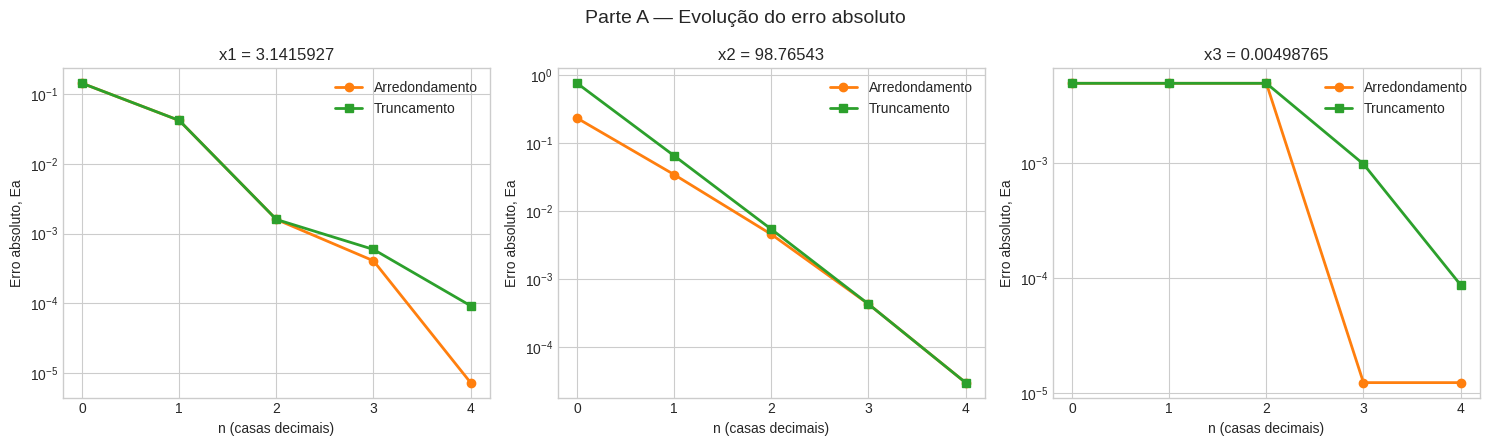

In [ ]:
# Cria uma figura com um painel para cada valor estudado.
figura, eixos = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)

# Percorre os valores e os painéis correspondentes.
for eixo, nome in zip(eixos, valores_parte_a):
    dados_valor = tabela_a[tabela_a["Valor"] == nome]

    # Desenha uma curva para cada método.
    for metodo, cor, marcador in [
        ("Arredondamento", COR_ARREDONDADO, "o"),
        ("Truncamento", COR_TRUNCADO, "s"),
    ]:
        dados_metodo = dados_valor[dados_valor["Método"] == metodo]
        eixo.semilogy(
            dados_metodo["n (casas decimais)"],
            dados_metodo["Ea (adimensional)"],
            marker=marcador,
            linewidth=2,
            color=cor,
            label=metodo,
        )

    eixo.set_xlabel("n (casas decimais)")
    eixo.set_ylabel("Erro absoluto, Ea")
    eixo.set_title(f"{nome} = {valores_parte_a[nome]:.8g}")
    eixo.set_xticks(casas_testadas)
    eixo.legend()

figura.suptitle("Parte A — Evolução do erro absoluto", fontsize=14)
figura.tight_layout()
plt.show()

### Resposta da Parte A

Nos casos avaliados, o arredondamento sempre produziu erro menor ou igual ao truncamento. Isso ocorre porque o arredondamento escolhe o valor representável mais próximo na quantidade de casas pedida, enquanto o truncamento apenas elimina os algarismos posteriores. Quando o primeiro algarismo descartado é menor que 5, os dois métodos podem coincidir e gerar o mesmo erro; quando ele é maior ou igual a 5, o arredondamento normalmente reduz o erro.

# Parte B — Medidas de pressão arterial

A análise abaixo é exclusivamente numérica e não faz interpretação médica. A média dos dados originais, com todos os algarismos disponíveis, é usada como referência.

In [ ]:
# Armazena as dez medições fornecidas, em mmHg.
dados_originais = np.array(
    [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5],
    dtype=float,
)

# Cria as representações inteiras pedidas.
dados_arredondados = np.round(dados_originais, 0)
dados_truncados = np.trunc(dados_originais)

# Calcula a média de referência com todos os algarismos disponíveis.
media_referencia = np.mean(dados_originais)

# Organiza as três séries em um dicionário.
series_pressao = {
    "Original": dados_originais,
    "Arredondada": dados_arredondados,
    "Truncada": dados_truncados,
}

# Cria uma lista para receber as estatísticas de cada série.
resultados_b = []

# Percorre as séries e calcula as estatísticas solicitadas.
for nome, serie in series_pressao.items():
    media = np.mean(serie)
    erro_abs, erro_rel, erro_percentual = calcular_erros(
        media_referencia, media
    )

    resultados_b.append({
        "Série": nome,
        "Média (mmHg)": media,
        "Mínimo (mmHg)": np.min(serie),
        "Máximo (mmHg)": np.max(serie),
        "Amplitude (mmHg)": np.max(serie) - np.min(serie),
        "Desvio-padrão amostral (mmHg)": np.std(serie, ddof=1),
        "Ea da média (mmHg)": erro_abs,
        "Er da média (adimensional)": erro_rel,
        "E% da média (%)": erro_percentual,
    })

tabela_b = pd.DataFrame(resultados_b)
print(f"Média de referência: {media_referencia:.6f} mmHg")
display(tabela_b)

Média de referência: 121.120000 mmHg


,Série,Média (mmHg),Mínimo (mmHg),Máximo (mmHg),Amplitude (mmHg),Desvio-padrão amostral (mmHg),Ea da média (mmHg),Er da média (adimensional),E% da média (%)
0,Original,1.21120000e+02,1.19800000e+02,1.22400000e+02,2.60000000e+00,8.33733237e-01,0.00000000e+00,0.00000000e+00,0.00000000e+00
1,Arredondada,1.21100000e+02,1.20000000e+02,1.22000000e+02,2.00000000e+00,8.75595036e-01,2.00000000e-02,1.65125495e-04,1.65125495e-02
2,Truncada,1.20700000e+02,1.19000000e+02,1.22000000e+02,3.00000000e+00,9.48683298e-01,4.20000000e-01,3.46763540e-03,3.46763540e-01


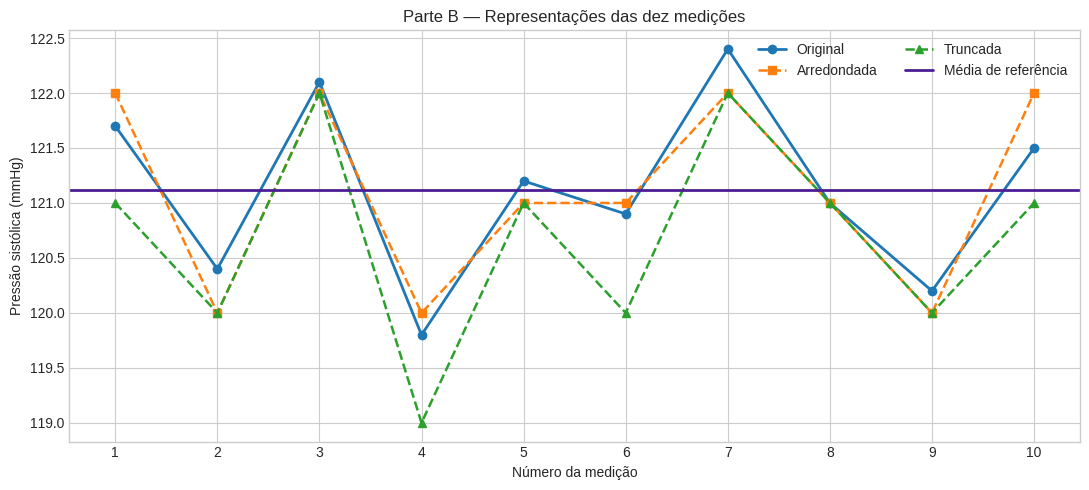

In [ ]:
# Cria o eixo horizontal com o número de cada medição.
medicoes = np.arange(1, len(dados_originais) + 1)

# Cria uma figura para comparar as três séries e a média de referência.
plt.figure(figsize=(11, 5))
plt.plot(medicoes, dados_originais, "o-", linewidth=2, color=COR_ORIGINAL, label="Original")
plt.plot(medicoes, dados_arredondados, "s--", linewidth=1.8, color=COR_ARREDONDADO, label="Arredondada")
plt.plot(medicoes, dados_truncados, "^--", linewidth=1.8, color=COR_TRUNCADO, label="Truncada")
plt.axhline(media_referencia, color=COR_REFERENCIA, linewidth=2, label="Média de referência")
plt.xlabel("Número da medição")
plt.ylabel("Pressão sistólica (mmHg)")
plt.title("Parte B — Representações das dez medições")
plt.xticks(medicoes)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

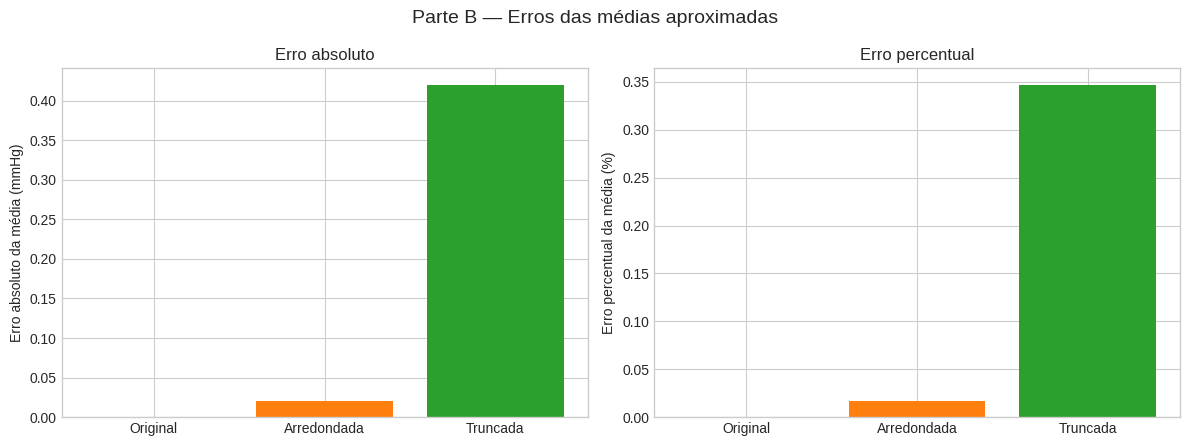

In [ ]:
# Cria dois gráficos de barras, um para Ea e outro para E%.
figura, eixos = plt.subplots(1, 2, figsize=(12, 4.5))

cores_barras = [COR_ORIGINAL, COR_ARREDONDADO, COR_TRUNCADO]
eixos[0].bar(tabela_b["Série"], tabela_b["Ea da média (mmHg)"], color=cores_barras)
eixos[0].set_ylabel("Erro absoluto da média (mmHg)")
eixos[0].set_title("Erro absoluto")

eixos[1].bar(tabela_b["Série"], tabela_b["E% da média (%)"], color=cores_barras)
eixos[1].set_ylabel("Erro percentual da média (%)")
eixos[1].set_title("Erro percentual")

figura.suptitle("Parte B — Erros das médias aproximadas", fontsize=14)
figura.tight_layout()
plt.show()

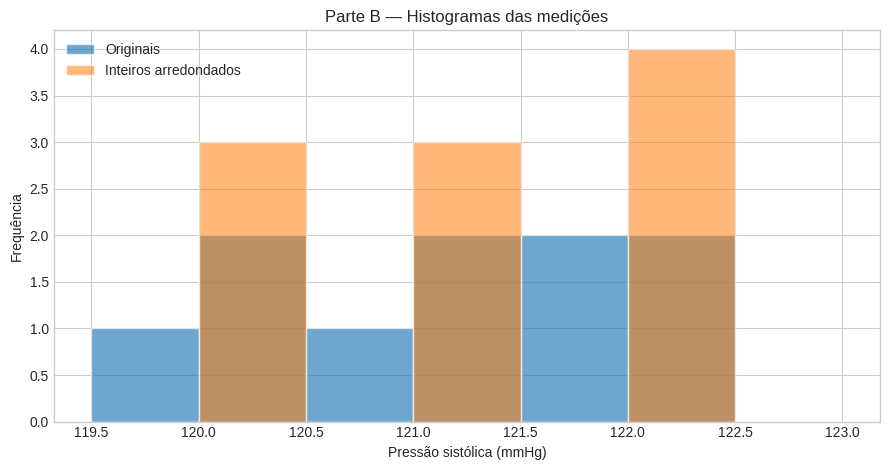

In [ ]:
# Define classes comuns para tornar os histogramas comparáveis.
classes = np.arange(119.5, 123.1, 0.5)

# Constrói os histogramas dos dados pedidos.
plt.figure(figsize=(9, 4.8))
plt.hist(dados_originais, bins=classes, alpha=0.65, color=COR_ORIGINAL, edgecolor="white", label="Originais")
plt.hist(dados_arredondados, bins=classes, alpha=0.55, color=COR_ARREDONDADO, edgecolor="white", label="Inteiros arredondados")
plt.xlabel("Pressão sistólica (mmHg)")
plt.ylabel("Frequência")
plt.title("Parte B — Histogramas das medições")
plt.legend()
plt.tight_layout()
plt.show()

### Resposta da Parte B

A representação inteira preservou a média de forma razoável nesta amostra, mas não preservou exatamente a variabilidade. O arredondamento alterou pouco a média, enquanto o truncamento introduziu um deslocamento sistemático para baixo. O desvio-padrão e a amplitude também mudaram porque valores distintos passaram a ocupar os mesmos inteiros. Portanto, a representação inteira pode servir para uma visão aproximada, mas perde informação relevante quando diferenças de décimos precisam ser comparadas.

# Parte C — Vazão em um tubo de pequeno diâmetro

Será utilizada a relação de Hagen–Poiseuille:

$$Q=\frac{\pi r^4\Delta p}{8\mu L}.$$

Todas as entradas são convertidas para o Sistema Internacional antes do cálculo.

In [ ]:
# Define os valores de referência no SI.
raio_mm = 0.80
raio_m = raio_mm * 1e-3
comprimento_m = 0.20
viscosidade_pa_s = 3.5e-3
delta_p_pa = 1200.0

# Calcula a vazão de referência.
vazao_referencia_c = calcular_vazao(
    raio_m, comprimento_m, viscosidade_pa_s, delta_p_pa
)

# Calcula as entradas aproximadas separadamente.
raio_arred_mm = round(raio_mm, 1)
raio_trunc_mm = truncar(raio_mm, 1)
mu_arred = round(viscosidade_pa_s, 3)
mu_trunc = truncar(viscosidade_pa_s, 3)
dp_arred = round(delta_p_pa, -2)
dp_trunc = truncar(delta_p_pa, -2)

# Organiza todos os cenários pedidos.
cenarios_c = [
    ("Referência", raio_mm, viscosidade_pa_s, delta_p_pa),
    ("r arredondado (1 casa em mm)", raio_arred_mm, viscosidade_pa_s, delta_p_pa),
    ("r truncado (1 casa em mm)", raio_trunc_mm, viscosidade_pa_s, delta_p_pa),
    ("μ arredondada (3 casas em Pa·s)", raio_mm, mu_arred, delta_p_pa),
    ("μ truncada (3 casas em Pa·s)", raio_mm, mu_trunc, delta_p_pa),
    ("Δp arredondada (centenas de Pa)", raio_mm, viscosidade_pa_s, dp_arred),
    ("Δp truncada (centenas de Pa)", raio_mm, viscosidade_pa_s, dp_trunc),
    ("Todas arredondadas", raio_arred_mm, mu_arred, dp_arred),
    ("Todas truncadas", raio_trunc_mm, mu_trunc, dp_trunc),
]

resultados_c1 = []

# Calcula a vazão e os erros de cada cenário.
for nome, raio_usado_mm, mu_usada, dp_usada in cenarios_c:
    vazao = calcular_vazao(
        raio_usado_mm * 1e-3,
        comprimento_m,
        mu_usada,
        dp_usada,
    )
    erro_abs, erro_rel, erro_percentual = calcular_erros(
        vazao_referencia_c, vazao
    )
    resultados_c1.append({
        "Cenário": nome,
        "r (mm)": raio_usado_mm,
        "μ (Pa·s)": mu_usada,
        "Δp (Pa)": dp_usada,
        "Q (m³/s)": vazao,
        "Ea de Q (m³/s)": erro_abs,
        "Er de Q (adimensional)": erro_rel,
        "E% de Q (%)": erro_percentual,
    })

tabela_c1 = pd.DataFrame(resultados_c1)
print(f"Vazão de referência: {vazao_referencia_c:.12e} m³/s")
display(tabela_c1)

Vazão de referência: 2.757420751951e-07 m³/s


,Cenário,r (mm),μ (Pa·s),Δp (Pa),Q (m³/s),Ea de Q (m³/s),Er de Q (adimensional),E% de Q (%)
0,Referência,8.00000000e-01,3.50000000e-03,1.20000000e+03,2.75742075e-07,0.00000000e+00,0.00000000e+00,0.00000000e+00
1,r arredondado (1 casa em mm),8.00000000e-01,3.50000000e-03,1.20000000e+03,2.75742075e-07,0.00000000e+00,0.00000000e+00,0.00000000e+00
2,r truncado (1 casa em mm),8.00000000e-01,3.50000000e-03,1.20000000e+03,2.75742075e-07,0.00000000e+00,0.00000000e+00,0.00000000e+00
3,μ arredondada (3 casas em Pa·s),8.00000000e-01,4.00000000e-03,1.20000000e+03,2.41274316e-07,3.44677594e-08,1.25000000e-01,1.25000000e+01
4,μ truncada (3 casas em Pa·s),8.00000000e-01,3.00000000e-03,1.20000000e+03,3.21699088e-07,4.59570125e-08,1.66666667e-01,1.66666667e+01
5,Δp arredondada (centenas de Pa),8.00000000e-01,3.50000000e-03,1.20000000e+03,2.75742075e-07,0.00000000e+00,0.00000000e+00,0.00000000e+00
6,Δp truncada (centenas de Pa),8.00000000e-01,3.50000000e-03,1.20000000e+03,2.75742075e-07,0.00000000e+00,0.00000000e+00,0.00000000e+00
7,Todas arredondadas,8.00000000e-01,4.00000000e-03,1.20000000e+03,2.41274316e-07,3.44677594e-08,1.25000000e-01,1.25000000e+01
8,Todas truncadas,8.00000000e-01,3.00000000e-03,1.20000000e+03,3.21699088e-07,4.59570125e-08,1.66666667e-01,1.66666667e+01


**Leitura da tabela C.1:** aproximar $r=0{,}80$ mm para uma casa decimal e $\Delta p=1200$ Pa para centenas não altera esses valores. A maior mudança nesta combinação ocorre em $\mu=0{,}0035$ Pa·s: o arredondamento para três casas gera $0{,}004$ Pa·s e o truncamento gera $0{,}003$ Pa·s. Como a viscosidade aparece no denominador, aumentar $\mu$ diminui $Q$ e reduzi-la aumenta $Q$.

## C.2 Sensibilidade ao raio

O raio varia de 0,70 a 0,90 mm em passos de 0,001 mm. As aproximações de uma casa decimal produzem curvas em degraus, enquanto a vazão de referência varia continuamente.

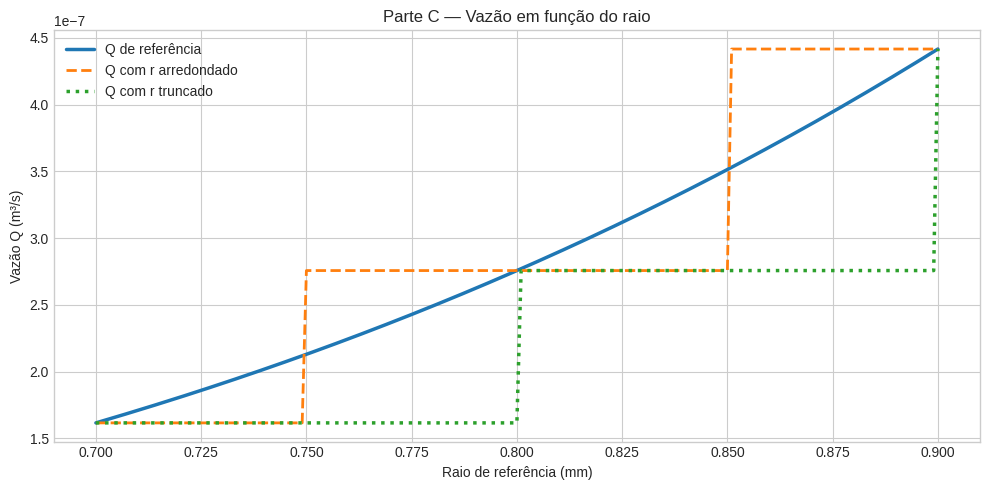

In [ ]:
# Cria 201 valores igualmente espaçados entre 0,70 e 0,90 mm.
raios_mm_c = np.linspace(0.70, 0.90, 201)

# Arredonda e trunca cada raio para uma casa decimal em milímetros.
raios_arred_mm_c = np.round(raios_mm_c, 1)
raios_trunc_mm_c = truncar_vetor(raios_mm_c, 1)

# Calcula as vazões para cada conjunto de raios.
vazao_c = calcular_vazao(raios_mm_c * 1e-3, comprimento_m, viscosidade_pa_s, delta_p_pa)
vazao_arred_c = calcular_vazao(raios_arred_mm_c * 1e-3, comprimento_m, viscosidade_pa_s, delta_p_pa)
vazao_trunc_c = calcular_vazao(raios_trunc_mm_c * 1e-3, comprimento_m, viscosidade_pa_s, delta_p_pa)

# Calcula os três tipos de erro em forma vetorial.
erro_abs_arred_c = np.abs(vazao_c - vazao_arred_c)
erro_abs_trunc_c = np.abs(vazao_c - vazao_trunc_c)
erro_rel_arred_c = erro_abs_arred_c / np.abs(vazao_c)
erro_rel_trunc_c = erro_abs_trunc_c / np.abs(vazao_c)
erro_perc_arred_c = 100.0 * erro_rel_arred_c
erro_perc_trunc_c = 100.0 * erro_rel_trunc_c

# Constrói o gráfico Q em função do raio.
plt.figure(figsize=(10, 5))
plt.plot(raios_mm_c, vazao_c, linewidth=2.5, color=COR_ORIGINAL, label="Q de referência")
plt.plot(raios_mm_c, vazao_arred_c, "--", linewidth=2, color=COR_ARREDONDADO, label="Q com r arredondado")
plt.plot(raios_mm_c, vazao_trunc_c, ":", linewidth=2.5, color=COR_TRUNCADO, label="Q com r truncado")
plt.xlabel("Raio de referência (mm)")
plt.ylabel("Vazão Q (m³/s)")
plt.title("Parte C — Vazão em função do raio")
plt.legend()
plt.tight_layout()
plt.show()

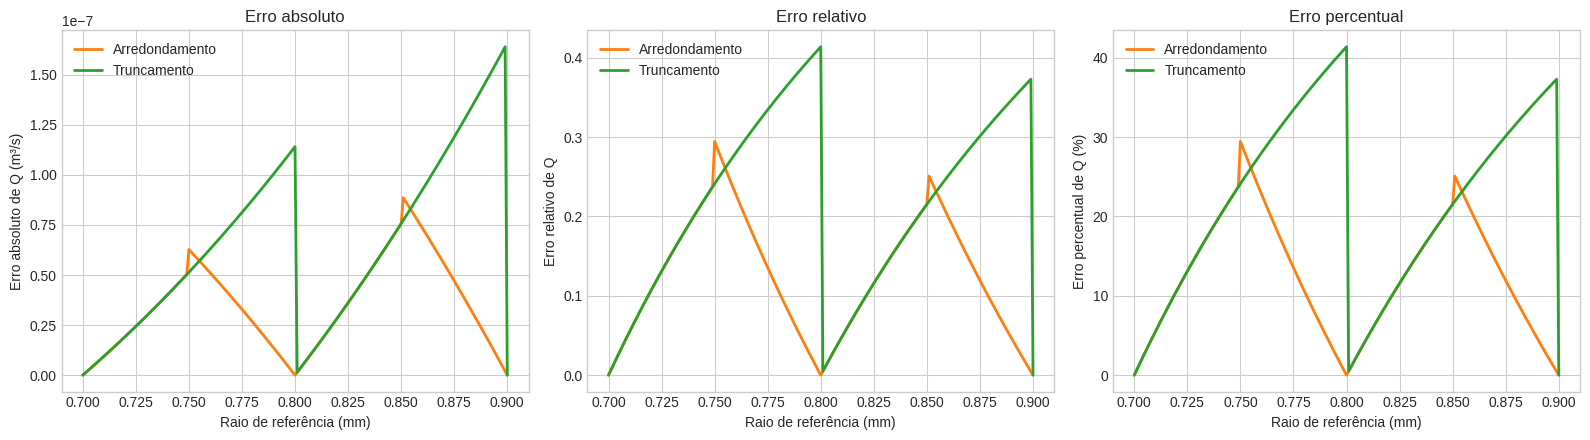

In [ ]:
# Cria três painéis para os erros absoluto, relativo e percentual.
figura, eixos = plt.subplots(1, 3, figsize=(16, 4.5))

conjuntos_erros = [
    (erro_abs_arred_c, erro_abs_trunc_c, "Erro absoluto de Q (m³/s)", "Erro absoluto"),
    (erro_rel_arred_c, erro_rel_trunc_c, "Erro relativo de Q", "Erro relativo"),
    (erro_perc_arred_c, erro_perc_trunc_c, "Erro percentual de Q (%)", "Erro percentual"),
]

for eixo, (erro_arred, erro_truncado, rotulo_y, titulo) in zip(eixos, conjuntos_erros):
    eixo.plot(raios_mm_c, erro_arred, linewidth=2, color=COR_ARREDONDADO, label="Arredondamento")
    eixo.plot(raios_mm_c, erro_truncado, linewidth=2, color=COR_TRUNCADO, label="Truncamento")
    eixo.set_xlabel("Raio de referência (mm)")
    eixo.set_ylabel(rotulo_y)
    eixo.set_title(titulo)
    eixo.legend()

figura.tight_layout()
plt.show()

### Resposta da Parte C

O erro do raio é amplificado porque a vazão é proporcional a $r^4$. Para uma pequena perturbação, a linearização fornece $\Delta Q/Q\approx4\,\Delta r/r$. Assim, um erro relativo pequeno no raio produz aproximadamente quatro vezes esse erro relativo na vazão. A relação não é exatamente linear para variações maiores porque a expansão completa contém também termos de segunda, terceira e quarta ordens.

# Parte D — Escoamento em um nanocateter

Dados do modelo didático: $r=50$ nm, $L=10$ µm, $\mu=3{,}5\times10^{-3}$ Pa·s e $\Delta p=5000$ Pa.

In [ ]:
# Converte os dados do nanocateter para o Sistema Internacional.
raio_nm_d = 50.0
raio_m_d = raio_nm_d * 1e-9
comprimento_m_d = 10.0e-6
viscosidade_d = 3.5e-3
delta_p_d = 5000.0

# Calcula a vazão de referência do nanocateter.
vazao_referencia_d = calcular_vazao(
    raio_m_d, comprimento_m_d, viscosidade_d, delta_p_d
)

print(f"Q(50 nm) = {vazao_referencia_d:.16e} m³/s")

Q(50 nm) = 3.5062418008814665e-19 m³/s


## D.1 Erro geométrico

Para cada erro geométrico entre 0,1 e 5,0 nm, são calculadas as vazões nos raios inferior e superior. O maior desvio em módulo é usado como erro máximo.

In [ ]:
# Cria os erros geométricos de 0,1 a 5,0 nm.
delta_raio_nm = np.arange(0.1, 5.0 + 0.1, 0.1)

# Calcula os raios inferior e superior em metros.
raio_menos_m = (raio_nm_d - delta_raio_nm) * 1e-9
raio_mais_m = (raio_nm_d + delta_raio_nm) * 1e-9

# Calcula as vazões correspondentes.
vazao_menos_d = calcular_vazao(raio_menos_m, comprimento_m_d, viscosidade_d, delta_p_d)
vazao_mais_d = calcular_vazao(raio_mais_m, comprimento_m_d, viscosidade_d, delta_p_d)

# Calcula o maior erro absoluto entre os dois lados.
erro_abs_menos_d = np.abs(vazao_menos_d - vazao_referencia_d)
erro_abs_mais_d = np.abs(vazao_mais_d - vazao_referencia_d)
erro_abs_max_d = np.maximum(erro_abs_menos_d, erro_abs_mais_d)

# Converte o erro máximo em erro relativo e percentual.
erro_rel_max_d = erro_abs_max_d / abs(vazao_referencia_d)
erro_perc_max_d = 100.0 * erro_rel_max_d

# Calcula a aproximação linear pedida.
aproximacao_linear_d = 4.0 * delta_raio_nm / raio_nm_d

# Organiza os resultados em uma tabela com unidades.
tabela_d1 = pd.DataFrame({
    "Δr (nm)": delta_raio_nm,
    "r− (nm)": raio_nm_d - delta_raio_nm,
    "r+ (nm)": raio_nm_d + delta_raio_nm,
    "Q(r−) (m³/s)": vazao_menos_d,
    "Q(r) (m³/s)": vazao_referencia_d,
    "Q(r+) (m³/s)": vazao_mais_d,
    "Ea máximo (m³/s)": erro_abs_max_d,
    "Er máximo": erro_rel_max_d,
    "E% máximo (%)": erro_perc_max_d,
    "4Δr/r (aprox. linear)": aproximacao_linear_d,
})
display(tabela_d1)

,Δr (nm),r− (nm),r+ (nm),Q(r−) (m³/s),Q(r) (m³/s),Q(r+) (m³/s),Ea máximo (m³/s),Er máximo,E% máximo (%),4Δr/r (aprox. linear)
0,1.00000000e-01,4.99000000e+01,5.01000000e+01,3.47827590e-19,3.50624180e-19,3.53437600e-19,2.81341965e-21,8.02403202e-03,8.02403202e-01,8.00000000e-03
1,2.00000000e-01,4.98000000e+01,5.02000000e+01,3.45047763e-19,3.50624180e-19,3.56267917e-19,5.64373665e-21,1.60962563e-02,1.60962563e+00,1.60000000e-02
2,3.00000000e-01,4.97000000e+01,5.03000000e+01,3.42284632e-19,3.50624180e-19,3.59115199e-19,8.49101854e-21,2.42168653e-02,2.42168653e+00,2.40000000e-02
3,4.00000000e-01,4.96000000e+01,5.04000000e+01,3.39538129e-19,3.50624180e-19,3.61979513e-19,1.13553330e-20,3.23860521e-02,3.23860521e+00,3.20000000e-02
4,5.00000000e-01,4.95000000e+01,5.05000000e+01,3.36808188e-19,3.50624180e-19,3.64860928e-19,1.42367477e-20,4.06040100e-02,4.06040100e+00,4.00000000e-02
5,6.00000000e-01,4.94000000e+01,5.06000000e+01,3.34094742e-19,3.50624180e-19,3.67759511e-19,1.71353307e-20,4.88709327e-02,4.88709327e+00,4.80000000e-02
6,7.00000000e-01,4.93000000e+01,5.07000000e+01,3.31397725e-19,3.50624180e-19,3.70675330e-19,2.00511500e-20,5.71870144e-02,5.71870144e+00,5.60000000e-02
7,8.00000000e-01,4.92000000e+01,5.08000000e+01,3.28717070e-19,3.50624180e-19,3.73608454e-19,2.29842739e-20,6.55524495e-02,6.55524495e+00,6.40000000e-02
8,9.00000000e-01,4.91000000e+01,5.09000000e+01,3.26052710e-19,3.50624180e-19,3.76558951e-19,2.59347705e-20,7.39674330e-02,7.39674330e+00,7.20000000e-02
9,1.00000000e+00,4.90000000e+01,5.10000000e+01,3.23404580e-19,3.50624180e-19,3.79526889e-19,2.89027085e-20,8.24321600e-02,8.24321600e+00,8.00000000e-02


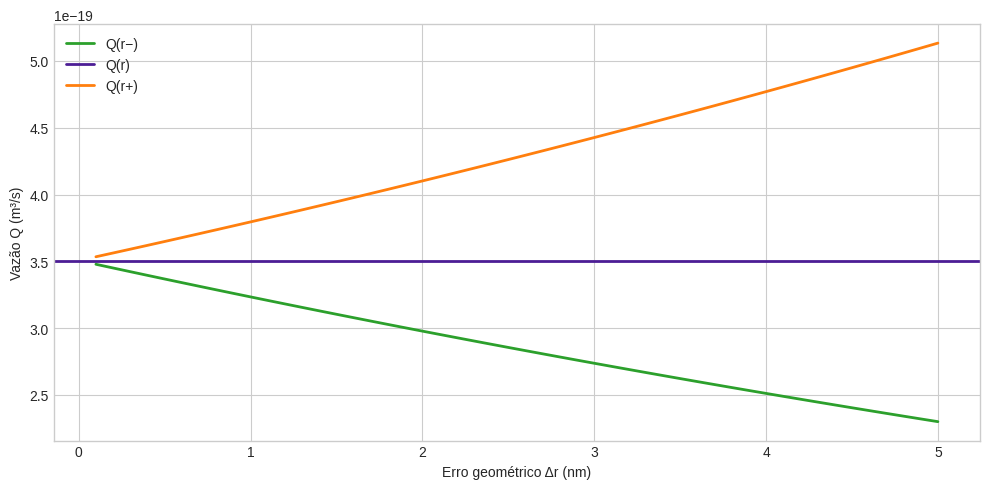

In [ ]:
# Constrói o gráfico das três vazões.
plt.figure(figsize=(10, 5))
plt.plot(delta_raio_nm, vazao_menos_d, linewidth=2, color=COR_TRUNCADO, label="Q(r−)")
plt.axhline(vazao_referencia_d, linewidth=2, color=COR_REFERENCIA, label="Q(r)")
plt.plot(delta_raio_nm, vazao_mais_d, linewidth=2, color=COR_ARREDONDADO, label="Q(r+)")
plt.xlabel("Erro geométrico Δr (nm)")
plt.ylabel("Vazão Q (m³/s)")
plt.legend()
plt.tight_layout()
plt.show()

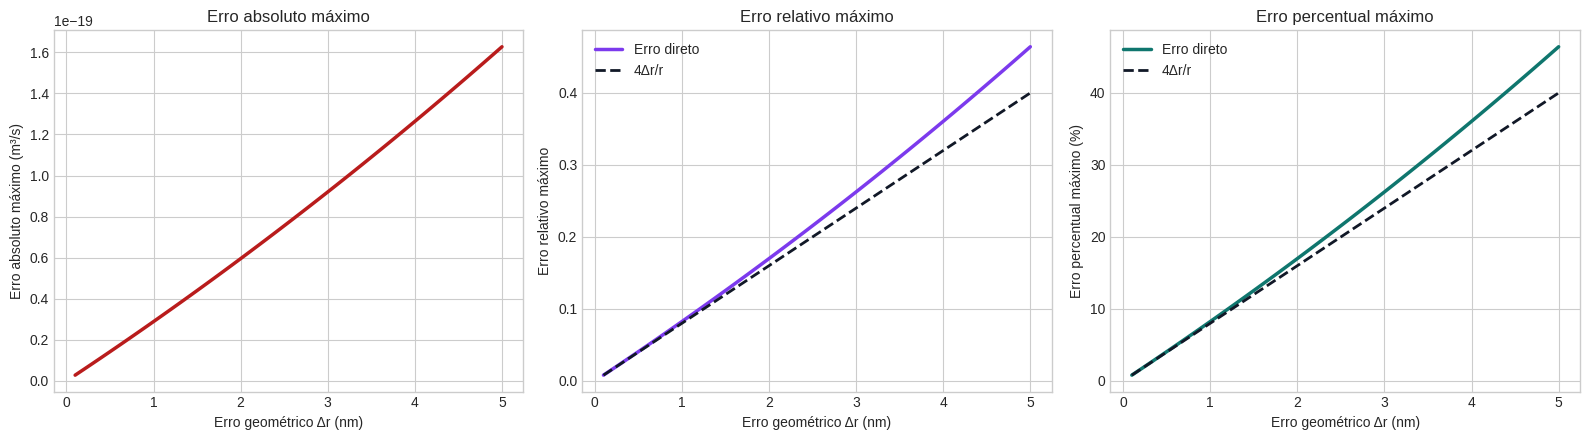

In [ ]:
# Cria os três gráficos de erro.
figura, eixos = plt.subplots(1, 3, figsize=(16, 4.5))

eixos[0].plot(delta_raio_nm, erro_abs_max_d, linewidth=2.5, color="#b91c1c")
eixos[0].set_ylabel("Erro absoluto máximo (m³/s)")
eixos[0].set_title("Erro absoluto máximo")

eixos[1].plot(delta_raio_nm, erro_rel_max_d, linewidth=2.5, color="#7c3aed", label="Erro direto")
eixos[1].plot(delta_raio_nm, aproximacao_linear_d, "--", linewidth=2, color="#111827", label="4Δr/r")
eixos[1].set_ylabel("Erro relativo máximo")
eixos[1].set_title("Erro relativo máximo")
eixos[1].legend()

eixos[2].plot(delta_raio_nm, erro_perc_max_d, linewidth=2.5, color="#0f766e", label="Erro direto")
eixos[2].plot(delta_raio_nm, 100.0 * aproximacao_linear_d, "--", linewidth=2, color="#111827", label="4Δr/r")
eixos[2].set_ylabel("Erro percentual máximo (%)")
eixos[2].set_title("Erro percentual máximo")
eixos[2].legend()

for eixo in eixos:
    eixo.set_xlabel("Erro geométrico Δr (nm)")

figura.tight_layout()
plt.show()

**Comparação com a aproximação linear:** para valores muito pequenos de $\Delta r/r$, o erro relativo direto fica próximo de $4\Delta r/r$. À medida que a perturbação cresce, o lado $r+\Delta r$ passa a dominar o erro máximo e os termos de ordem superior da potência quarta tornam a curva direta maior que a aproximação linear.

## D.2 Precisão computacional

O cálculo é repetido com `numpy.float32` e `numpy.float64`, mantendo as operações dentro do tipo numérico escolhido.

In [ ]:
# Define uma função que força todas as operações para a precisão escolhida.
def vazao_numpy(tipo):
    pi_tipo = tipo(np.pi)
    r_tipo = tipo(50.0e-9)
    l_tipo = tipo(10.0e-6)
    mu_tipo = tipo(3.5e-3)
    dp_tipo = tipo(5000.0)
    r_quarta = tipo(r_tipo ** tipo(4.0))
    q_tipo = tipo(
        (pi_tipo * r_quarta * dp_tipo)
        / (tipo(8.0) * mu_tipo * l_tipo)
    )
    return r_quarta, q_tipo


# Calcula r⁴ e Q nas duas precisões.
r4_float32, q_float32 = vazao_numpy(np.float32)
r4_float64, q_float64 = vazao_numpy(np.float64)

# Calcula as diferenças tomando float64 como referência computacional.
diferenca_abs_q = abs(float(q_float64) - float(q_float32))
diferenca_rel_q = diferenca_abs_q / abs(float(q_float64))

# Organiza os resultados pedidos em uma tabela.
tabela_d2 = pd.DataFrame({
    "Tipo": ["float32", "float64"],
    "r⁴ (m⁴)": [float(r4_float32), float(r4_float64)],
    "Q (m³/s)": [float(q_float32), float(q_float64)],
    "np.finfo(...).eps": [np.finfo(np.float32).eps, np.finfo(np.float64).eps],
})

display(tabela_d2)
print(f"Diferença absoluta entre Q64 e Q32: {diferenca_abs_q:.16e} m³/s")
print(f"Diferença relativa entre Q64 e Q32: {diferenca_rel_q:.16e}")

,Tipo,r⁴ (m⁴),Q (m³/s),np.finfo(...).eps
0,float32,6.25000040e-30,3.50624232e-19,1.19209290e-07
1,float64,6.25000000e-30,3.50624180e-19,2.22044605e-16


Diferença absoluta entre Q64 e Q32: 5.2286276891843277e-26 m³/s
Diferença relativa entre Q64 e Q32: 1.4912342006389455e-07


In [ ]:
# Define razões Δr/r progressivamente menores.
razoes = 10.0 ** (-np.arange(1, 17, dtype=float))

# Calcula δ1 pela diferença entre duas vazões e δ2 pela razão geométrica.
def comparar_cancelamento(tipo, razoes_entrada):
    resultados = []
    r = tipo(50.0e-9)
    l = tipo(10.0e-6)
    mu = tipo(3.5e-3)
    dp = tipo(5000.0)
    pi_tipo = tipo(np.pi)

    def q_local(raio):
        return tipo((pi_tipo * raio ** tipo(4.0) * dp) / (tipo(8.0) * mu * l))

    q_base = q_local(r)

    for razao in razoes_entrada:
        h = tipo(razao)
        delta_r = tipo(r * h)
        delta_1 = tipo((q_local(tipo(r + delta_r)) - q_base) / q_base)
        delta_2 = tipo((tipo(1.0) + h) ** tipo(4.0) - tipo(1.0))

        # Forma estável usada apenas como comparação numérica.
        delta_estavel = tipo(np.expm1(tipo(4.0) * np.log1p(h)))

        resultados.append({
            "Tipo": np.dtype(tipo).name,
            "Δr/r": float(h),
            "δ1": float(delta_1),
            "δ2": float(delta_2),
            "forma estável": float(delta_estavel),
            "|δ1-estável|": abs(float(delta_1) - float(delta_estavel)),
            "|δ2-estável|": abs(float(delta_2) - float(delta_estavel)),
        })
    return resultados


resultados_cancelamento = []
resultados_cancelamento.extend(comparar_cancelamento(np.float32, razoes[:10]))
resultados_cancelamento.extend(comparar_cancelamento(np.float64, razoes))
tabela_cancelamento = pd.DataFrame(resultados_cancelamento)

print("Comparação em float32:")
display(tabela_cancelamento[tabela_cancelamento["Tipo"] == "float32"])
print("Comparação em float64:")
display(tabela_cancelamento[tabela_cancelamento["Tipo"] == "float64"])

Comparação em float32:


,Tipo,Δr/r,δ1,δ2,forma estável,|δ1-estável|,|δ2-estável|
0,float32,1.00000001e-01,4.64100063e-01,4.64100122e-01,4.64100003e-01,5.96046448e-08,1.19209290e-07
1,float32,9.99999978e-03,4.06037457e-02,4.06039953e-02,4.06040102e-02,2.64495611e-07,1.49011612e-08
2,float32,1.00000005e-03,4.00601048e-03,4.00614738e-03,4.00600443e-03,6.05359674e-09,1.42958015e-07
3,float32,9.99999975e-05,3.99878569e-04,4.00185585e-04,4.00060002e-04,1.81433279e-07,1.25583028e-07
4,float32,9.99999975e-06,4.01058132e-05,4.00543213e-05,4.00005993e-05,1.05213985e-07,5.37220330e-08
5,float32,9.99999997e-07,3.90736795e-06,3.81469727e-06,4.00000636e-06,9.26384018e-08,1.85309091e-07
6,float32,1.00000001e-07,2.21171774e-07,4.76837158e-07,4.00000062e-07,1.78828287e-07,7.68370967e-08
7,float32,9.99999994e-09,0.00000000e+00,0.00000000e+00,3.99999998e-08,3.99999998e-08,3.99999998e-08
8,float32,9.99999972e-10,0.00000000e+00,0.00000000e+00,3.99999989e-09,3.99999989e-09,3.99999989e-09
9,float32,1.00000001e-10,0.00000000e+00,0.00000000e+00,4.00000005e-10,4.00000005e-10,4.00000005e-10


Comparação em float64:


,Tipo,Δr/r,δ1,δ2,forma estável,|δ1-estável|,|δ2-estável|
10,float64,1.00000000e-01,4.64100000e-01,4.64100000e-01,4.64100000e-01,4.99600361e-16,3.33066907e-16
11,float64,1.00000000e-02,4.06040100e-02,4.06040100e-02,4.06040100e-02,3.40005801e-16,2.08166817e-17
12,float64,1.00000000e-03,4.00600400e-03,4.00600400e-03,4.00600400e-03,2.90566182e-16,5.14345511e-16
13,float64,1.00000000e-04,4.00060004e-04,4.00060004e-04,4.00060004e-04,1.66045563e-16,1.53089347e-16
14,float64,1.00000000e-05,4.00006000e-05,4.00006000e-05,4.00006000e-05,1.92683055e-16,3.08482623e-16
15,float64,1.00000000e-06,4.00000600e-06,4.00000600e-06,4.00000600e-06,1.73650225e-17,2.43752365e-16
16,float64,1.00000000e-07,4.00000060e-07,4.00000060e-07,4.00000060e-07,2.75692284e-16,1.85586189e-16
17,float64,1.00000000e-08,4.00000006e-08,4.00000004e-08,4.00000006e-08,3.15937334e-18,1.76965028e-16
18,float64,1.00000000e-09,3.99999969e-09,4.00000033e-09,4.00000001e-09,3.16452192e-16,3.24961484e-16
19,float64,1.00000000e-10,4.00000038e-10,4.00000033e-10,4.00000000e-10,3.75555455e-17,3.30361484e-17


### Interpretação da precisão computacional

`float64` possui epsilon de máquina muito menor e, por isso, conserva mais algarismos em $r^4$ e em $Q$. Para razões $\Delta r/r$ progressivamente menores, $r+\Delta r$ acaba sendo representado como o próprio $r$. Nesse ponto, $Q(r+\Delta r)-Q(r)$ se torna zero em `δ1`, embora a variação matemática ainda exista. A expressão `δ2` também contém uma subtração de números próximos e eventualmente perde informação. A coluna de forma estável, baseada em `log1p` e `expm1`, mostra a variação esperada por mais tempo. Esse é o cancelamento numérico discutido nas aulas.

## D.3 Fenômeno físico

Quando a escala do canal diminui, a razão entre superfície e volume aumenta. Com isso, uma fração maior do fluido fica próxima da parede, onde os efeitos viscosos, a condição de não deslizamento e as interações de superfície se tornam proporcionalmente mais importantes. A equação de Hagen–Poiseuille é útil como modelo didático, mas supõe fluido contínuo, geometria cilíndrica ideal, escoamento laminar e propriedades uniformes. Em escala nanométrica, essas hipóteses podem deixar de representar adequadamente o sistema. Portanto, muitas casas decimais indicam precisão aritmética, não garantem validade física do modelo.

# Parte E — Quadro único de resultados

O quadro abaixo é salvo em PNG com exatamente 1600 × 1000 pixels e reúne os principais resultados solicitados.

In [ ]:
# Obtém valores resumidos usados nos cartões.
media_arred_b = tabela_b.loc[tabela_b["Série"] == "Arredondada", "Média (mmHg)"].iloc[0]
media_trunc_b = tabela_b.loc[tabela_b["Série"] == "Truncada", "Média (mmHg)"].iloc[0]
erro32_percentual = 100.0 * diferenca_rel_q

# Cria uma figura de 16 × 10 polegadas a 100 dpi: 1600 × 1000 pixels.
figura = plt.figure(figsize=(16, 10), dpi=100, facecolor="#f8fafc")
grade = figura.add_gridspec(3, 4, height_ratios=[0.9, 1.7, 1.7], hspace=0.38, wspace=0.34)

# Define uma função auxiliar para desenhar cartões.
def criar_cartao(eixo, titulo, valor, subtitulo, cor):
    eixo.set_facecolor("white")
    for borda in eixo.spines.values():
        borda.set_color("#cbd5e1")
    eixo.set_xticks([])
    eixo.set_yticks([])
    eixo.text(0.06, 0.78, titulo, transform=eixo.transAxes, fontsize=11, color="#475569", weight="bold")
    eixo.text(0.06, 0.43, valor, transform=eixo.transAxes, fontsize=18, color=cor, weight="bold")
    eixo.text(0.06, 0.15, subtitulo, transform=eixo.transAxes, fontsize=9.5, color="#64748b")

criar_cartao(figura.add_subplot(grade[0, 0]), "PRESSÃO", f"{media_referencia:.2f} mmHg", "média de referência", COR_ORIGINAL)
criar_cartao(figura.add_subplot(grade[0, 1]), "VAZÃO — TUBO", f"{vazao_referencia_c:.3e} m³/s", "r = 0,80 mm", COR_TRUNCADO)
criar_cartao(figura.add_subplot(grade[0, 2]), "VAZÃO — NANOCATETER", f"{vazao_referencia_d:.3e} m³/s", "r = 50 nm", COR_REFERENCIA)
criar_cartao(figura.add_subplot(grade[0, 3]), "FLOAT32 × FLOAT64", f"{erro32_percentual:.3e}%", "diferença percentual em Q", COR_ARREDONDADO)

# Compara o erro absoluto médio dos métodos da Parte A.
eixo_a = figura.add_subplot(grade[1, 0:2])
medias_ea_a = tabela_a.groupby("Método")["Ea (adimensional)"].mean().reindex(["Arredondamento", "Truncamento"])
eixo_a.bar(medias_ea_a.index, medias_ea_a.values, color=[COR_ARREDONDADO, COR_TRUNCADO])
eixo_a.set_ylabel("Erro absoluto médio")
eixo_a.set_title("Truncamento × arredondamento", weight="bold")

# Mostra os três tipos de erro para a média truncada da Parte B.
eixo_erros = figura.add_subplot(grade[1, 2:4])
linha_trunc_b = tabela_b[tabela_b["Série"] == "Truncada"].iloc[0]
valores_erros = [
    linha_trunc_b["Ea da média (mmHg)"],
    linha_trunc_b["Er da média (adimensional)"],
    linha_trunc_b["E% da média (%)"],
]
barras = eixo_erros.bar(["Ea (mmHg)", "Er", "E% (%)"], valores_erros, color=["#2563eb", "#7c3aed", "#db2777"])
eixo_erros.set_title("Três erros — média truncada", weight="bold")
eixo_erros.bar_label(barras, fmt="%.3g", padding=3)

# Exibe a sensibilidade da vazão ao raio.
eixo_sens = figura.add_subplot(grade[2, 0:2])
eixo_sens.plot(raios_mm_c, vazao_c, linewidth=2.5, color=COR_ORIGINAL, label="Referência")
eixo_sens.plot(raios_mm_c, vazao_arred_c, "--", linewidth=2, color=COR_ARREDONDADO, label="r arredondado")
eixo_sens.plot(raios_mm_c, vazao_trunc_c, ":", linewidth=2.5, color=COR_TRUNCADO, label="r truncado")
eixo_sens.set_xlabel("Raio (mm)")
eixo_sens.set_ylabel("Q (m³/s)")
eixo_sens.set_title("Sensibilidade de Q ao raio", weight="bold")
eixo_sens.legend(fontsize=9)

# Compara o erro direto com a aproximação linear no nanocateter.
eixo_nano = figura.add_subplot(grade[2, 2:4])
eixo_nano.plot(delta_raio_nm, erro_perc_max_d, linewidth=2.5, color="#0f766e", label="Erro direto")
eixo_nano.plot(delta_raio_nm, 100.0 * aproximacao_linear_d, "--", linewidth=2, color="#111827", label="4Δr/r")
eixo_nano.set_xlabel("Δr (nm)")
eixo_nano.set_ylabel("Erro máximo (%)")
eixo_nano.set_title("Nanocateter: potência quarta amplifica o erro", weight="bold")
eixo_nano.legend(fontsize=9)


caminho_quadro = pasta_saida / "quadro_sintese_atividade_I.png"
figura.savefig(caminho_quadro, dpi=100, bbox_inches=None, facecolor=figura.get_facecolor())
plt.show()

# Confirma as dimensões do arquivo salvo.
from PIL import Image as PILImage
with PILImage.open(caminho_quadro) as imagem_quadro:

_IncompleteInputError: incomplete input (656235114.py, line 71)

# GIF demonstrativo

O GIF possui 45 quadros. O raio varia de 45 a 55 nm; cada quadro mostra a seção transversal, o raio atual, a vazão, o erro percentual em relação a 50 nm e a curva Q × r sendo construída.

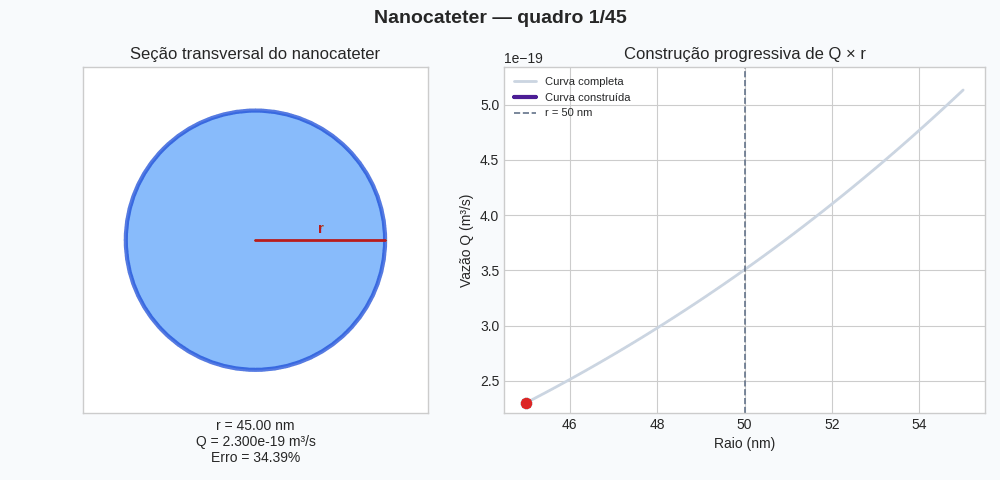

In [ ]:
# Cria 45 valores de raio entre 45 e 55 nm.
raios_gif_nm = np.linspace(45.0, 55.0, 45)
raios_gif_m = raios_gif_nm * 1e-9

# Calcula a vazão correspondente a cada raio.
vazoes_gif = calcular_vazao(
    raios_gif_m, comprimento_m_d, viscosidade_d, delta_p_d
)

# Calcula o erro percentual em relação à vazão em r = 50 nm.
erros_gif_percentuais = 100.0 * np.abs(vazoes_gif - vazao_referencia_d) / abs(vazao_referencia_d)

# Cria a figura com dois painéis.
figura_gif, (eixo_canal, eixo_curva) = plt.subplots(1, 2, figsize=(10, 4.8), facecolor="#f8fafc")

# Define a função que desenha cada quadro da animação.
def atualizar_quadro(indice):
    eixo_canal.clear()
    eixo_curva.clear()

    raio_atual = raios_gif_nm[indice]
    vazao_atual = vazoes_gif[indice]
    erro_atual = erros_gif_percentuais[indice]

    # Desenha a seção transversal do canal em escala comum.
    circulo = Circle((0, 0), raio_atual, facecolor="#60a5fa", edgecolor="#1d4ed8", linewidth=3, alpha=0.75)
    eixo_canal.add_patch(circulo)
    eixo_canal.plot([0, raio_atual], [0, 0], color="#b91c1c", linewidth=2)
    eixo_canal.text(raio_atual / 2, 2.5, "r", color="#b91c1c", ha="center", fontsize=11, weight="bold")
    eixo_canal.set_xlim(-60, 60)
    eixo_canal.set_ylim(-60, 60)
    eixo_canal.set_aspect("equal")
    eixo_canal.set_title("Seção transversal do nanocateter")
    eixo_canal.set_xlabel(f"r = {raio_atual:.2f} nm\nQ = {vazao_atual:.3e} m³/s\nErro = {erro_atual:.2f}%")
    eixo_canal.set_xticks([])
    eixo_canal.set_yticks([])

    # Constrói progressivamente a curva Q × r.
    eixo_curva.plot(raios_gif_nm, vazoes_gif, color="#cbd5e1", linewidth=2, label="Curva completa")
    eixo_curva.plot(raios_gif_nm[: indice + 1], vazoes_gif[: indice + 1], color=COR_REFERENCIA, linewidth=3, label="Curva construída")
    eixo_curva.scatter([raio_atual], [vazao_atual], color="#dc2626", s=55, zorder=3)
    eixo_curva.axvline(50.0, color="#64748b", linestyle="--", linewidth=1.2, label="r = 50 nm")
    eixo_curva.set_xlim(44.5, 55.5)
    eixo_curva.set_ylim(vazoes_gif.min() * 0.96, vazoes_gif.max() * 1.04)
    eixo_curva.set_xlabel("Raio (nm)")
    eixo_curva.set_ylabel("Vazão Q (m³/s)")
    eixo_curva.set_title("Construção progressiva de Q × r")
    eixo_curva.legend(loc="upper left", fontsize=8)

    figura_gif.suptitle(f"Nanocateter — quadro {indice + 1}/45", fontsize=14, weight="bold")
    figura_gif.tight_layout()

# Cria e salva a animação com 45 quadros.
animacao = FuncAnimation(
    figura_gif,
    atualizar_quadro,
    frames=len(raios_gif_nm),
    interval=125,
    repeat=True,
)

caminho_gif = pasta_saida / "nanocateter_variacao_raio.gif"
animacao.save(caminho_gif, writer=PillowWriter(fps=8), dpi=100)
plt.close(figura_gif)

display(Image(filename=str(caminho_gif)))

# Conclusão

Os resultados mostram que arredondamento e truncamento não produzem necessariamente o mesmo efeito: o arredondamento seleciona a aproximação mais próxima, enquanto o truncamento pode introduzir um viés, como observado na média das pressões. Na equação de Hagen–Poiseuille, a potência quarta torna a vazão muito sensível ao raio, de modo que pequenas variações geométricas são amplificadas. A comparação entre `float32` e `float64` também mostrou que a precisão finita e o cancelamento podem ocultar variações muito pequenas. Por fim, mesmo um cálculo numericamente preciso pode ser fisicamente inadequado se as hipóteses do modelo contínuo não forem válidas na escala nanométrica.